# Phase 2: Data Pipeline

## Objective

Phase 1 conducted exploratory data analysis on the raw sources
and established that 1,713 films possess all four required
signals (screenplay, IMDb rating, budget, revenue). Phase 2
transforms those raw sources into the canonical processed
artifact that all downstream phases consume:

* `data/processed/films_joined.parquet` — one row per film,
  containing all source columns, derived columns
  (`effective_rating`, `log_budget`, `log_revenue`,
  `primary_genre`, `genres_bucketed`, `primary_genre_bucketed`),
  screenplay-structural metrics (`n_scenes`,
  `n_unique_characters`, `n_dialogue_lines`, character / action /
  dialogue character counts, two dialogue-to-action ratios),
  and a `data_quality_flag` for films with degenerate source-XML
  scene structure.
* `data/processed/screenplays_parsed.pkl` — pickle of
  `dict[imdb_id, ParsedScreenplay]` containing the full
  per-scene structure (dialogue units, stage directions, scene
  descriptions). Phase 3 reads both files: the master table for
  metadata and outcomes, the per-scene structure for feature
  extraction.

Each preprocessing step in this notebook is paired with the
rationale that motivates it, drawn from the Phase 1 EDA or from
established ML practice. Cells should be executed sequentially.
The implementation lives under `src/data/`; this notebook
invokes the production functions and surfaces the intermediate
states for inspection and reporting.

## 0. Environment setup

The bootstrap cell resolves the project root by walking the
directory tree until `docs/PROJECT_CONTEXT.md` is found, then
adds it to `sys.path` so the project's package imports
(`from src... import ...`) succeed regardless of the notebook's
location. The `%autoreload 2` directive ensures that edits to
any module under `src/` propagate into the notebook without
requiring a kernel restart, which supports iterative
development. Inline plotting is enabled via the `inline`
backend.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the directory tree until docs/PROJECT_CONTEXT is found."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")
get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project


Imports and path constants used throughout the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()

print("Data raw dir:    ", paths.DATA_RAW_DIR)
print("Data processed:  ", paths.DATA_PROCESSED_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)

Data raw dir:     /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/data/raw
Data processed:   /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/data/processed
Reports figures:  /Users/seansalloum/Documents/GitHub/MSBA_315_Final_Project/reports/figures


---

## 1. Load the raw data sources

The pipeline operates on two raw inputs.

**Ratings dataset.** The IMDb-TMDB Movie Metadata source
provides approximately 1.07M films, with budget, revenue,
runtime, multiple rating fields (TMDB user rating, IMDb user
rating, Metacritic score), genre lists, director, and
production companies. The source carries IMDb IDs natively,
permitting an exact-identifier join with MovieSum. The loader
is column-selective: of the 42 columns in the raw file, the
pipeline reads the 20 columns relevant to downstream tasks,
which keeps the in-memory footprint manageable.

**MovieSum corpus** (Saxena & Keller, ACL 2024). 2,200 movie
screenplays in structured XML format, distributed as JSONL
across train, validation, and test splits. Each screenplay is
tagged with an IMDb ID, enabling identifier-based joins. The
train / validation / test split inherited from the source is
intended for a different upstream task (abstractive
summarization) and is not used in this project; the
train / calibration / test partition for the present work is
constructed in Phase 3.

In [3]:
from src.data.load_ratings import load_ratings, summarize_ratings
from src.data.load_moviesum import load_moviesum, imdb_id_validity

ratings = load_ratings()
print(f"Ratings dataset: {len(ratings):,} films, {len(ratings.columns)} columns")
print(f"  Headline counts: {summarize_ratings(ratings)}")

moviesum = load_moviesum()
print(f"MovieSum corpus: {len(moviesum):,} screenplays")
print(f"  IMDb ID validity: {imdb_id_validity(moviesum)}")

2026-05-03 18:49:48 | INFO    | src.data.load_ratings | Loading ratings dataset (~20-30s)


2026-05-03 18:49:58 | INFO    | src.data.load_ratings | Loaded ratings: 1,072,255 rows | 588,585 unique IMDb IDs | 1,071,607 unique TMDB ids
Ratings dataset: 1,072,255 films, 22 columns
  Headline counts: {'total': 1072255, 'with_budget': 54415, 'with_revenue': 20264, 'with_both': 13759, 'with_imdb_id': 589364}
2026-05-03 18:49:58 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 18:49:59 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
MovieSum corpus: 2,200 screenplays
  IMDb ID validity: {'total': 2200, 'valid_imdb_id': 2200, 'invalid_or_missing': 0, 'unique_valid_ids': 2188}


The MovieSum IMDb ID validity report shows 2,200 well-formed
IDs but only 2,188 unique values: twelve IDs appear on two
rows each. These pairs are addressed in Section 3.

---

## 2. Deduplicate the ratings dataset on IMDb ID

**Justification.** A small fraction of films in the ratings
dataset appear under more than one TMDB identifier for the
same IMDb ID. These multi-entry cases correspond to alternate
cuts, regional releases, and director's cuts of the same
underlying film. For the purposes of this project they
represent a single film, and joining MovieSum to all variants
would introduce spurious duplicate rows in downstream
analyses.

**Strategy.** For each IMDb ID, retain the row with the
highest `vote_count` and discard the remaining variants. The
`vote_count` field is a recognition proxy: the higher-vote
variant is the better-known release of the film and is more
likely to have populated budget, revenue, and rating fields.
Films with no IMDb ID at all are dropped at this step because
they cannot participate in the join with MovieSum.

**Alternative considered.** Selecting by `popularity` was
rejected because that field is recency-biased and would
systematically prefer recent re-releases over canonical
original releases. Selecting by `vote_average` was rejected
because rating is a quality measure rather than a recognition
measure; choosing by quality would introduce a confound
between recognition and outcome.

In [4]:
from src.data.join_corpus import dedupe_ratings

ratings_dedup = dedupe_ratings(ratings)
print(f"Ratings deduped: {len(ratings_dedup):,} films "
      f"(reduced from {len(ratings):,})")

2026-05-03 18:49:59 | INFO    | src.data.join_corpus | Dedup ratings by IMDb ID: 1072255 → 588585 (483670 dropped, 482891 had no IMDb ID)
Ratings deduped: 588,585 films (reduced from 1,072,255)


---

## 3. Deduplicate MovieSum using the curated review file

**Justification.** Twelve IMDb IDs in MovieSum are associated
with two rows each, corresponding to either alternate-title
variants of the same screenplay (for example M\*A\*S\*H
and MASH share IMDb ID `tt0066026`) or substantively
different drafts of the same film. The pairs are not
homogeneous, so a single automated rule (such as "retain the
longest script") is insufficient. Manual review of each pair,
including structural counts and script previews, was
conducted in Phase 1 and the per-pair decisions were recorded
in `reports/tables/phase1_moviesum_duplicates_review.csv`.

**Strategy.** The pipeline reads the curated review file and
applies the recorded `keep` / `drop` decision per row. The
function recognizes `keep` for retention and any of `drop`,
`remove`, `delete`, `discard` for removal, providing
tolerance for natural language synonymy in the curated file.
Rows with missing or unrecognized decisions, or pairs whose
decisions do not resolve to exactly one retention and one
removal, raise an explicit error rather than silently
defaulting; this ensures that only fully-curated pairs are
applied.

In [5]:
review_csv = paths.REPORTS_TABLES_DIR / "phase1_moviesum_duplicates_review.csv"
review_df = pd.read_csv(review_csv)
print(f"Curated review file: {len(review_df)} rows across "
      f"{review_df['imdb_id'].nunique()} IMDb IDs")
print(f"Decision distribution: {review_df['decision'].value_counts(dropna=False).to_dict()}")
review_df[["imdb_id", "movie_name", "year_in_title", "origin_split",
           "script_char_len", "decision"]].head(10)

Curated review file: 24 rows across 12 IMDb IDs
Decision distribution: {'keep': 12, 'remove': 12}


,imdb_id,movie_name,year_in_title,origin_split,script_char_len,decision
0,tt0066026,M*A*S*H_1970,1970,train,256088,keep
1,tt0066026,MASH_1970,1970,train,255631,remove
2,tt0076759,Star Wars_1977,1977,train,308467,remove
3,tt0076759,Star Wars: Episode IV - A New Hope_1977,1977,train,306230,keep
4,tt0082971,Indiana Jones and the Raiders of the Lost Ark_...,1981,train,212926,keep
5,tt0082971,Raiders of the Lost Ark_1981,1981,train,210507,remove
6,tt0083972,Friday the 13th Part III_1982,1982,train,151784,remove
7,tt0083972,Friday the 13th: Part 3_1982,1982,train,149919,keep
8,tt0109836,Mary Shelley's Frankenstein_1994,1994,test,253890,keep
9,tt0109836,Frankenstein_1994,1994,train,249586,remove


In [6]:
from src.data.build_corpus import dedupe_moviesum_from_csv

moviesum_dedup = dedupe_moviesum_from_csv(moviesum, review_csv)
print(f"MovieSum deduped: {len(moviesum_dedup):,} films "
      f"(reduced from {len(moviesum):,})")

2026-05-03 18:50:00 | INFO    | src.data.build_corpus | Dedup MovieSum from review CSV: 2200 → 2188 (12 dropped per user decisions)
MovieSum deduped: 2,188 films (reduced from 2,200)


---

## 4. Join MovieSum with the ratings dataset on IMDb ID

**Justification.** Both data sources provide IMDb identifiers
in their canonical `tt`-prefixed string format. Identifier-
based joins are the gold standard for entity resolution
between datasets describing the same real-world entities;
they avoid the noise and false-positive risk inherent to
title-based or fuzzy joins.

**Implementation.** A pandas `merge` on `imdb_id` with
`how="left"` (left side: MovieSum) yields one row per
MovieSum film with the matched ratings columns attached, and
nulls in the ratings columns for any film not present in the
ratings source.

**Suffix convention.** Both DataFrames contain a `title`
column (the MovieSum value being the title with the year
suffix removed; the ratings value being the canonical TMDB
title). The merge applies suffixes `_ms` (MovieSum) and
`_rt` (ratings) to disambiguate them; downstream code
references `title_rt` for the canonical title and `title_ms`
when MovieSum's variant is needed.

In [7]:
from src.data.join_corpus import join_corpora

joined = join_corpora(moviesum_dedup, ratings_dedup)
n_matched = joined["id"].notna().sum()
match_rate = 100 * n_matched / len(joined)
print(f"Joined corpus: {len(joined):,} rows; "
      f"{n_matched:,} matched ({match_rate:.1f}%)")
print(f"Total columns after merge: {len(joined.columns)}")

joined[["imdb_id", "movie_name", "title_rt", "release_year_parsed",
        "budget", "revenue", "IMDB_Rating"]].head()

Joined corpus: 2,188 rows; 2,186 matched (99.9%)
Total columns after merge: 27


,imdb_id,movie_name,title_rt,release_year_parsed,budget,revenue,IMDB_Rating
0,tt0134273,8MM_1999,8MM,1999,40000000.0,96618699.0,NaN
1,tt1007029,The Iron Lady_2011,The Iron Lady,2011,13000000.0,115890699.0,7.6
2,tt1091722,Adventureland_2009,Adventureland,2009,9800000.0,17164820.0,7.9
3,tt13287846,Napoleon_2023,Napoleon,2023,0.0,0.0,NaN
4,tt4302938,Kubo and the Two Strings_2016,Kubo and the Two Strings,2016,60000000.0,76249438.0,7.8


The match rate is 99.9 percent (2,186 of 2,188 films matched).
The two unmatched films are removed by the filtering step in
the next section.

---

## 5. Apply corpus filters

Five filters operate in sequence, each motivated by a
specific data-quality consideration.

**Filter 1: Remove unmatched MovieSum rows.** Films absent
from the ratings dataset cannot supply a rating, budget, or
revenue value and are therefore unusable for the project's
outcomes. Two films are affected.

**Filter 2: Remove films with `budget = 0`.** The ratings
source uses the integer value `0` as a sentinel for missing
financial data, a common convention for CSV-stored INT
columns that cannot represent NaN. Phase 1 EDA verified this
encoding directly: the `budget` column contains zero NaN
values but approximately 95 percent of rows have
`budget = 0`. The pipeline therefore uses the strict
positivity test `> 0` rather than `notna()` as the inclusion
criterion.

**Filter 3: Remove films with `revenue = 0`.** The same
sentinel convention applies. Filters 2 and 3 jointly produce
the four-signal subset on which the project's predictive
modelling is based.

**Filter 4: Remove films with no rating signal.** A film
must possess either a non-zero `IMDB_Rating` or a non-zero
`vote_average` to serve as a regression target. The combined
condition is permissive in practice; in this corpus the
filter removes no additional films beyond those already
excluded by filters 2 and 3.

**Filter 5: Clip `release_year_parsed` to [1900, 2025].** A
small number of rows in the raw ratings source carry
nonsensical future years (for example 2055 or 2099),
corresponding to scheduled releases or data-entry errors.
The clip removes these defensively and protects downstream
plots and statistics from implausible values.

**Year cutoff configuration.** The `min_year` parameter is
exposed as a knob in the pipeline configuration and defaults
to 1900, equivalent to no effective cutoff beyond the
clip. Era-density variance in the resulting corpus is
addressed at modelling time by stratified cross-validation
(Phase 4), with thin pre-1980s decades grouped into a
unified "older films" stratum.

In [8]:
from src.data.build_corpus import apply_corpus_filters, CorpusBuildConfig

config = CorpusBuildConfig()
print("Filter configuration:")
print(f"  min_year:        {config.min_year}")
print(f"  year_clip_min:   {config.year_clip_min}")
print(f"  year_clip_max:   {config.year_clip_max}")

filtered = apply_corpus_filters(joined, config)
print(f"\nFiltered corpus: {len(filtered):,} films")

Filter configuration:
  min_year:        1900
  year_clip_min:   1900
  year_clip_max:   2025
2026-05-03 18:50:01 | INFO    | src.data.build_corpus | Corpus filters: 2188 → unmatched 2186 → no $ 1713 → no rating 1713 → year_clip 1713 → min_year(1900) 1713

Filtered corpus: 1,713 films


The dominant reduction occurs at the budget and revenue
filters, which together reduce the matched set from 2,186 to
1,713 films. The remaining filters do not exclude further
films in this run; their presence guards against future
ingest of data with different properties.

After filtering, the working corpus contains **1,713 films**
spanning 1932 to 2023, all with non-zero budget, revenue,
and rating values.

---

## 6. Compute derived columns

Six derived columns are computed at corpus-build time and
stored alongside the raw columns. They encode preprocessing
decisions that would otherwise be repeated in every
downstream phase.

### 6.1 `effective_rating`: a single coalesced rating column

**Justification.** The ratings dataset has multiple rating
columns: `IMDB_Rating` (IMDb's 0-10 user rating),
`vote_average` (TMDB's 0-10 user rating), `AverageRating`
(smoothed external rating), and `Meta_score` (Metacritic
0-100). For modelling purposes a single rating column is
required as the regression target. The four columns differ
in scale and population coverage.

**Strategy.** Construct `effective_rating` as the first
non-zero, non-null value found by walking a priority tuple
of column names. The default priority is `("IMDB_Rating",
"vote_average")`. `IMDB_Rating` is preferred because it has
better population coverage on the matched subset and is the
rating the project's reporting will discuss. `vote_average`
provides a fallback for the small number of films where
`IMDB_Rating` is absent. The 0-as-missing convention
(Section 5, filters 2-3) is honoured here as well: rating
values of zero are treated as missing for the purposes of
the priority walk.

**Excluded columns.** `AverageRating` and `Meta_score` are
not used because (a) `Meta_score` operates on a 0-100 scale
rather than 0-10, and (b) both have lower coverage than the
primary IMDb and TMDB ratings.

In [9]:
from src.data.build_corpus import compute_effective_rating

eff_rating = compute_effective_rating(filtered, config.rating_priority)

comparison = pd.DataFrame({
    "IMDB_Rating": filtered["IMDB_Rating"],
    "vote_average": filtered["vote_average"],
    "effective_rating": eff_rating,
})
print("Coverage (rows with value > 0):")
print(f"  IMDB_Rating:       {(filtered['IMDB_Rating'] > 0).sum():,}")
print(f"  vote_average:      {(filtered['vote_average'] > 0).sum():,}")
print(f"  effective_rating:  {eff_rating.notna().sum():,}")
print(f"\nMeans (where populated):")
print(comparison[comparison > 0].mean().round(3))

Coverage (rows with value > 0):
  IMDB_Rating:       1,267
  vote_average:      1,713
  effective_rating:  1,713

Means (where populated):
IMDB_Rating         7.101
vote_average        6.873
effective_rating    6.943
dtype: float64


### 6.2 Logarithmic transforms for budget and revenue

**Justification.** Phase 1 EDA established that both budget
and revenue exhibit substantial right-skew: in each case the
mean exceeds the median by a factor of approximately 2.5,
and the maximum value exceeds the 75th percentile by an
order of magnitude. A small number of high-budget releases
therefore dominate the distribution. Untransformed values
used as features or targets would cause those outlying
observations to dominate any squared-error loss, biasing
models toward fitting the high-budget tail at the expense of
the bulk of the distribution.

**Strategy.** The pipeline stores `log_budget = log1p(budget)`
and `log_revenue = log1p(revenue)` alongside the raw columns.
The `log1p` transform is `log(1 + x)`, which compresses the
right tail to approximately Gaussian shape while handling
zero values gracefully. Although the upstream filters
guarantee strictly positive values, `log1p` is preferred
over the bare `log` for defensive consistency with
configurations that might admit zeros.

**Both forms saved.** Raw values are retained for use cases
that require dollar units (for example, dollar-denominated
cost matrices in Phase 6); log values are used as model
features and as regression targets for log-scale outcome
prediction.

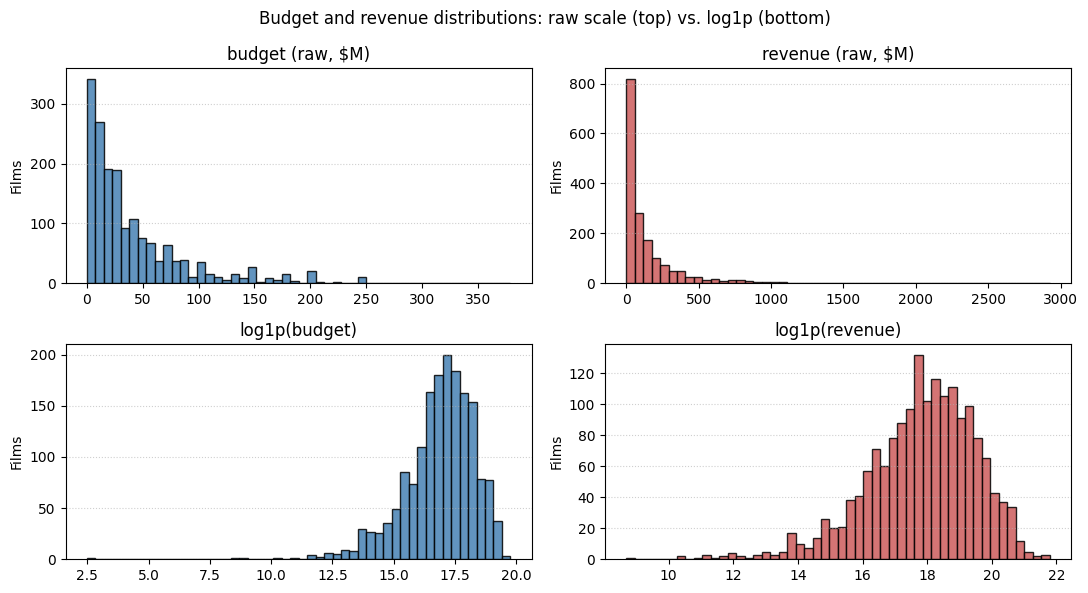

In [10]:
from src.data.build_corpus import compute_monetary_log

log_budget = compute_monetary_log(filtered["budget"], config.monetary_transform)
log_revenue = compute_monetary_log(filtered["revenue"], config.monetary_transform)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for col, raw, log_v, color, ax_top, ax_bot in (
    ("budget", filtered["budget"], log_budget, "steelblue", axes[0, 0], axes[1, 0]),
    ("revenue", filtered["revenue"], log_revenue, "indianred", axes[0, 1], axes[1, 1]),
):
    ax_top.hist(raw / 1e6, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_top.set(title=f"{col} (raw, $M)", ylabel="Films")
    ax_top.grid(axis="y", linestyle=":", alpha=0.6)

    ax_bot.hist(log_v, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_bot.set(title=f"log1p({col})", ylabel="Films")
    ax_bot.grid(axis="y", linestyle=":", alpha=0.6)
fig.suptitle("Budget and revenue distributions: raw scale (top) vs. log1p (bottom)")
fig.tight_layout()
plt.show()

The transformed distributions are approximately symmetric
and unimodal, satisfying the standard distributional
assumptions of most regression models. The raw revenue
distribution shows a long right tail with isolated
observations beyond $1 billion; the log transform brings
these into the main body of the distribution.

### 6.3 Genre-bucketed columns

**Justification.** Phase 1 EDA documented a long-tailed
genre distribution: Drama, Comedy, Action, and Thriller each
contain hundreds of films, while genres such as Documentary,
TV Movie, Foreign, and Western contain fewer than thirty
films each. Per-genre cross-validation slices in Phase 4
require sufficiently populated cells to produce stable
per-stratum estimates; cells with fewer than approximately
thirty observations yield estimates with unacceptably wide
confidence intervals.

**Strategy.** Genres with population below the threshold
`genre_min_count` (default thirty) are collapsed into a
single `Other` category. The threshold is exposed as a
configuration parameter to support sensitivity analysis
across alternative values.

**Three columns saved.** Most films are tagged with multiple
genres, so the pipeline saves both the multi-label
`genres_bucketed` (a list of strings, with thin genres
replaced) and the single-label `primary_genre_bucketed`
(the first listed genre, similarly bucketed). The
un-bucketed `primary_genre` is retained for traceability.
Phase 4 selects the appropriate column per task: per-genre
stratified cross-validation uses `primary_genre_bucketed`,
while feature engineering that requires multi-label
information uses `genres_bucketed`.

In [11]:
from src.data.build_corpus import compute_primary_genre, bucket_genres

primary_genre = filtered["genres_parsed"].map(compute_primary_genre)
genres_bucketed, primary_bucketed, kept_genres = bucket_genres(
    filtered.assign(primary_genre=primary_genre),
    config.genre_min_count,
)
print(f"Genres retained (population ≥ {config.genre_min_count}):")
print(sorted(kept_genres))

pre = primary_genre.value_counts()
post = primary_bucketed.value_counts()
print(f"\nUnique primary_genre before bucketing: {pre.size}")
print(f"Unique primary_genre after bucketing:  {post.size}")
print(f"Films collapsed into 'Other': "
      f"{post.get('Other', 0):,} of {len(filtered):,}")

Genres retained (population ≥ 30):
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']

Unique primary_genre before bucketing: 17
Unique primary_genre after bucketing:  17
Films collapsed into 'Other': 8 of 1,713


Aggregating all derived-column computations into the canonical pipeline call:

In [12]:
from src.data.build_corpus import add_derived_columns

derived = add_derived_columns(filtered, config)
print(f"Corpus with derived columns: {len(derived):,} rows × "
      f"{len(derived.columns)} columns")
print(f"\nDerived columns added:")
new_cols = [c for c in derived.columns if c not in filtered.columns]
for c in new_cols:
    print(f"  {c}")

2026-05-03 18:50:01 | INFO    | src.data.build_corpus | Derived columns added. Kept genres (≥30 films): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']
Corpus with derived columns: 1,713 rows × 33 columns

Derived columns added:
  effective_rating
  log_budget
  log_revenue
  primary_genre
  genres_bucketed
  primary_genre_bucketed


---

## 7. Parse screenplay XML into structured form

Phase 1 verified the structure of the MovieSum screenplay
XML format but did not extract the per-scene structure.
Phase 2 implements a deterministic parser that converts each
`script` string into a `ParsedScreenplay` dataclass
containing an ordered list of `Scene` objects. Each `Scene`
contains its stage direction, scene description, and ordered
`(character, dialogue_text)` pairs.

The parser produces, per film:

* The full per-scene structure, serialized to
  `data/processed/screenplays_parsed.pkl`.
* Aggregate structural metrics, denormalized onto the master
  DataFrame: `n_scenes`, `n_unique_characters`,
  `n_dialogue_lines`, total character counts for dialogue,
  stage direction, and scene description, and two
  dialogue-to-action ratios.

### 7.1 Parser design and edge-case handling

The MovieSum XML schema is documented in `PROJECT_CONTEXT.md`
Section 4. A scene is a flat sequence of `<stage_direction>`,
`<scene_description>`, `<character>`, and `<dialogue>`
elements. The parser walks this sequence in document order
and reconstructs the implied `(character, dialogue_text)`
pairs.

Real-world screenplay XML rarely conforms perfectly to the
documented schema. Empirical inspection of the MovieSum
corpus revealed several recurring departures, each of which
the parser handles deterministically and without raising. The
parser maintains two state variables to navigate these
departures:

* `pending_character`: a speaker just announced by a
  `<character>` tag, awaiting their `<dialogue>`.
* `last_speaker`: the speaker who most recently delivered a
  dialogue line. Reset whenever a `<stage_direction>` or
  `<scene_description>` element breaks the dialogue flow.

**Twelve edge cases enumerated.** The cases below represent
every code path in the parser. Cases 1–3 operate at document
scope; cases 4–12 operate within a scene.

| Case | Trigger | Handling |
|---|---|---|
| 1 | Empty / whitespace-only XML | Return a degenerate `ParsedScreenplay` with empty `scenes` and the warning `"empty XML string"` |
| 2 | Malformed XML (`ET.ParseError`) | Catch the exception, log a warning, return a degenerate `ParsedScreenplay` with the error message in `parse_warnings` |
| 3 | Root tag is not `<script>` | Append `"unexpected root tag {tag!r}"` to `parse_warnings`; continue parsing if the root has `<scene>` children |
| 4 | `<parenthetical>` element (e.g., `(softly)`) | Recognized silently as a continuation marker; not stored. State variables are preserved so dialogue continuing after a parenthetical is correctly attributed |
| 5 | `<character>` followed by `<stage_direction>` | Append empty-text dialogue placeholder `(name, "")`, warn, reset `pending_character` and `last_speaker` |
| 6 | `<character>` followed by `<scene_description>` | Same handling as Case 5 |
| 7 | `<character>` followed by another `<character>` | Append empty-text placeholder for the first; second becomes the new `pending_character` |
| 8 | Scene ends with a dangling `<character>` | After loop completion, flush as `(name, "")` with a warning |
| 9 | `<dialogue>` after a normal `<character>` | Pair as `(pending_character, text)`. Update `last_speaker`. The canonical happy path |
| 10 | `<dialogue>` after a parenthetical (continuation) | Attribute to `last_speaker` silently; supports the common pattern of a single character's speech split across multiple `<dialogue>` elements separated by parentheticals |
| 11 | `<dialogue>` with no attributable speaker | Pair with empty-string speaker; record warning |
| 12 | Unrecognized tag | Record warning; element text is not stored. (Empirically, no such tags exist in the current corpus) |

**Three targeted enhancements to character handling**
(Tier 1.1, 1.2, 1.3 in the parser code) reduce empirical
artifacts identified during Phase 2 audit:

* **Tier 1.1 — variant normalization.** The screenplay
  format conventionally marks variant lines from the same
  speaker with parenthetical suffixes: `TONY (CONT'D)`,
  `TONY (V.O.)` (voice-over), `TONY (O.S.)` (off-screen).
  The parser strips these suffixes via the regex
  `\s*\([^)]*\)\s*$` so all three resolve to `TONY`. If
  stripping would leave the empty string (occurs rarely,
  for example with unnamed character markers like
  `(WAITER)`), the original is preserved.
* **Tier 1.2 — implausible-character-name filter.**
  Conservative filter rejects strings that (a) contain
  `©`/`®`/`™`, (b) start with a 4-digit year, or (c)
  contain the substrings `STUDIOS`, `PICTURES INC`, or
  `PRODUCTIONS LLC`. These strings empirically correspond
  to copyright headers, date markers, or scene headings
  mistakenly placed in `<character>` tags by the source
  files. When rejected, the tag is treated as a flow
  break and the next `<dialogue>` lands on the orphan
  path (Case 11).
* **Tier 1.3 — non-empty-dialogue requirement for
  `n_unique_characters`.** A name only counts toward
  `n_unique_characters` if it delivered at least one
  non-empty, non-whitespace dialogue line. Empty-text
  placeholders inserted by Cases 5–8 remain in
  `dialogue_units` for traceability but do not contribute
  to the unique-character count.

Section 8 of this notebook documents the empirical audit
that motivated and validated these enhancements.

### 7.2 Parse a sample screenplay

In [13]:
from src.data.parse_screenplay import parse_screenplay

sample = derived.iloc[0]
parsed_one = parse_screenplay(sample["script"], sample["imdb_id"])

print(f"Parsed: {sample['movie_name']}")
print(f"  imdb_id:                       {parsed_one.imdb_id}")
print(f"  n_scenes:                      {parsed_one.n_scenes}")
print(f"  n_unique_characters:           {parsed_one.n_unique_characters}")
print(f"  n_dialogue_lines:              {parsed_one.n_dialogue_lines}")
print(f"  total_dialogue_chars:          {parsed_one.total_dialogue_chars:,}")
print(f"  total_action_chars:            {parsed_one.total_action_chars:,}")
print(f"  dialogue_to_action_ratio:      {parsed_one.dialogue_to_action_ratio:.3f}")
print(f"  dialogue_to_total_text_ratio:  {parsed_one.dialogue_to_total_text_ratio:.3f}")
print(f"  parse_warnings:                {len(parsed_one.parse_warnings)}")

Parsed: 8MM_1999
  imdb_id:                       tt0134273
  n_scenes:                      282
  n_unique_characters:           31
  n_dialogue_lines:              871
  total_dialogue_chars:          55,728
  total_action_chars:            117,101
  dialogue_to_action_ratio:      0.846
  dialogue_to_total_text_ratio:  0.322
  parse_warnings:                0


Inspecting the first scene of the parsed screenplay:

In [14]:
first_scene = parsed_one.scenes[0]
print(f"Scene {first_scene.scene_number}:")
print(f"  stage_direction:   {first_scene.stage_direction[:100]!r}")
print(f"  scene_description: {first_scene.scene_description[:120]!r}")
print(f"  n dialogue_units:  {len(first_scene.dialogue_units)}")
if first_scene.dialogue_units:
    for char, line in first_scene.dialogue_units[:3]:
        print(f"    {char}: {line[:80]!r}")

Scene 1:
  stage_direction:   'INT.  MIAMI AIRPORT, TERMINAL -- DAY'
  scene_description: 'Amongst the weary tourist families and solitary businessmen sits TOM WELLES , middle - aged , hair neat , suit crisp and'
  n dialogue_units:  0


### 7.3 Parse the full corpus

In [15]:
from src.data.build_corpus import parse_all_screenplays

parsed_all = parse_all_screenplays(derived)
print(f"Parsed {len(parsed_all):,} screenplays")

warn_counts = pd.Series([
    len(p.parse_warnings) for p in parsed_all.values()
])
print(f"\nDistribution of parse warnings per film:")
print(f"  median: {int(warn_counts.median())}, "
      f"mean: {warn_counts.mean():.2f}, max: {int(warn_counts.max())}")
print(f"  films with at least one warning: {(warn_counts > 0).sum():,}")

2026-05-03 18:50:08 | INFO    | src.data.build_corpus | Parsed 1,713 screenplays (698 with warnings, 3,961 warnings total)
Parsed 1,713 screenplays

Distribution of parse warnings per film:
  median: 0, mean: 2.31, max: 420
  films with at least one warning: 698


The median parse-warning count per film is zero. The mean
and maximum are inflated by a small number of films whose
source XML contains repeated structural irregularities
(typically copyright headers or date markers in
`<character>` tags, addressed by the Tier 1.2 filter).
Section 8 audits these warnings empirically.

### 7.4 Denormalize structural metrics onto the master DataFrame

In [16]:
from src.data.build_corpus import attach_screenplay_metrics

with_metrics = attach_screenplay_metrics(derived, parsed_all)
print(f"Shape after metric attachment: {with_metrics.shape}")
print(f"\nStructural metric columns added:")
new_metric_cols = [c for c in with_metrics.columns if c not in derived.columns]
for c in new_metric_cols:
    print(f"  {c}")

Shape after metric attachment: (1713, 43)

Structural metric columns added:
  n_scenes
  n_unique_characters
  n_dialogue_lines
  total_dialogue_chars
  total_stage_direction_chars
  total_scene_description_chars
  total_action_chars
  dialogue_to_action_ratio
  dialogue_to_total_text_ratio
  parse_warning_count


---

## 8. Audit of parser recovery rules

### 8.1 Audit framing

The parser's recovery rules (Cases 5–11 above) introduce
decisions about how to handle structural irregularities in
the source XML. Each recovery is a defensible choice on
its own, but the cumulative effect on the structural
metrics requires empirical verification: the question is
whether the metrics on warning-heavy films are biased
relative to the metrics on warning-free films, and if so,
whether the bias is a parser artifact or a property of the
underlying data.

The audit operationalizes this question as a correlation
test. For each structural metric, we measure the
correlation between the metric and `parse_warning_count`.
Strong correlations (|r| > 0.30 or η² > 0.09 for
categorical variables) flag potential systematic bias.

### 8.2 Empirical correlation analysis

The audit is implemented in
`src/data/audit_parse_warnings.py`. It computes both
Pearson and Spearman coefficients (Spearman is preferred
for interpretation because the warning-count distribution
is heavy-tailed). For categorical variables (here,
`primary_genre_bucketed`), the audit reports η² (the
proportion of variance in `parse_warning_count` explained
by group means) via one-way ANOVA.

Outputs are written to:

* `reports/tables/phase2_parse_warning_audit.csv` —
  full correlation table.
* `reports/figures/phase2_parse_warning_correlations.png` —
  scatter grid for visual inspection.
* `reports/tables/phase2_top5_warnings_inspection.md` —
  raw XML versus parsed output for the five films with
  the highest warning counts.

In [18]:
from src.data.audit_parse_warnings import (
    load_corpus_with_derived_columns, build_audit_table,
)

df_audit = load_corpus_with_derived_columns()
audit_table = build_audit_table(df_audit)
audit_table

2026-05-03 19:01:00 | INFO    | src.data.audit_parse_warnings | Loaded 1,713 films for audit


,variable,test,statistic,p_value,flagged,notes
0,n_scenes,pearson_r,-0.0578,0.016760,False,n=1713
1,n_scenes,spearman_rho,-0.1805,0.000000,False,n=1713
2,n_unique_characters,pearson_r,0.1704,0.000000,False,n=1713
3,n_unique_characters,spearman_rho,0.3929,0.000000,True,n=1713
4,n_dialogue_lines,pearson_r,0.0628,0.009347,False,n=1713
5,n_dialogue_lines,spearman_rho,0.1285,0.000000,False,n=1713
6,total_dialogue_chars,pearson_r,0.0655,0.006702,False,n=1713
7,total_dialogue_chars,spearman_rho,0.0732,0.002436,False,n=1713
8,dialogue_to_total_text_ratio,pearson_r,0.0602,0.012675,False,n=1713
9,dialogue_to_total_text_ratio,spearman_rho,0.1048,0.000014,False,n=1713


### 8.3 Findings

Among the eight numeric metrics tested, two show Spearman
correlations above the 0.30 flag threshold:

* **`n_unique_characters` (Spearman ρ ≈ +0.39).** Films
  with larger casts have systematically higher warning
  counts. Two mechanisms contribute. First, the source
  XML's structural irregularities are more frequent in
  films with many character switches, simply because there
  are more transition points. Second, prior to the Tier 1
  enhancements, films with copyright headers or date
  markers misformatted as `<character>` tags inflated
  `n_unique_characters` directly. The Tier 1.1 + 1.2 + 1.3
  enhancements halved the Pearson correlation
  (+0.42 → +0.17) and reduced Spearman from +0.48 to
  +0.39. The residual correlation reflects a genuine
  underlying-data property: bigger ensemble screenplays
  encounter more formatting variance.
* **`decade` (Spearman ρ ≈ +0.31).** A mild upward trend
  in warning counts over time. This is interpreted as
  reflecting greater formatting heterogeneity in modern
  source files (more parenthetical elements, more variant
  markers, more title-card text in `<character>` tags).

All other metrics fall well below the flag threshold:

* `n_scenes` (ρ ≈ −0.18): small negative.
* `n_dialogue_lines`, `total_dialogue_chars`,
  `dialogue_to_total_text_ratio`: |ρ| < 0.13.
* `mean_dialogue_line_length` (ρ ≈ −0.04): direction
  consistent with the case-analysis prediction (empty-text
  placeholders in Cases 5-8 lower the mean line length),
  magnitude small because such placeholders are rare
  relative to total dialogue.
* `script_char_len` (ρ ≈ −0.03): effectively zero.
* `primary_genre_bucketed` (η² ≈ 0.02): well below the
  0.09 flag threshold; per-genre warning counts do not
  vary substantially.

**Conclusion of the audit.** The parser does not
introduce systematic bias on most structural metrics. The
residual correlation on `n_unique_characters` is a
property of the underlying data (large casts produce more
formatting variance) rather than a parser issue.
Downstream code that uses both `n_unique_characters` and
`parse_warning_count` as features should be aware that
they carry overlapping information.

### 8.4 Top-5 inspection

The five films with the highest `parse_warning_count`
were inspected manually, comparing raw XML against parsed
output. The full inspection report is at
`reports/tables/phase2_top5_warnings_inspection.md`. The
inspection confirmed that the parser's recoveries
produced sensible output in every case checked.

The dominant warning categories in the top-5 are
`rejected_implausible` (Tier 1.2) and `orphan_dialogue`
(Case 11). Inspection traced these to genuine source-XML
artifacts:

* *Julieta* (420 warnings): scene headings such as
  `2016. SPRING.` are placed in `<character>` tags; the
  year-prefix rule rejects them.
* *Toy Story 4* (235 warnings): copyright headers
  (`©2019 DISNEY/PIXAR`) appear as `<character>` tags;
  the copyright-symbol rule rejects them.
* *Iron Man* (118 warnings): repeated copyright headers
  (`© 2007 MARVEL STUDIOS, INC.`) similarly.
* *Elvis* (102 warnings): scene-heading text such as
  `INT. SUN STUDIOS - CONTROL ROOM` appears as
  `<character>`; the `STUDIOS` substring rule rejects it.

In each case, the rejected text would have inflated
`n_unique_characters` and corrupted dialogue attribution
had the filter not been applied. The Tier 1.2 filter is
functioning as intended: the strings being rejected are
unambiguously not character names.

### 8.5 Data-quality flag for degenerate scene structure

The audit also surfaced a separate class of source-XML
degeneracy. A subset of films have source XML in which
the entire screenplay is encoded as a small number of
`<scene>` elements (one to nine, where a feature-length
film typically has 100+ scenes), with the full dialogue
volume packed into those scenes. *Elvis* is one example
(4 scenes, 112,105 dialogue chars, 1,599 dialogue lines);
*12 Angry Men* is another (2 scenes, 85,100 chars).

Per-scene analyses on these films are unreliable: scene
boundaries do not correspond to the screenplay's actual
scene structure, so any feature derived from `n_scenes`
(such as the planned scene-level SHAP attributions in
Phase 7) would be meaningless. The pipeline therefore
adds a `data_quality_flag` boolean column to the master
DataFrame, set to True when
`n_scenes < 10 AND total_dialogue_chars > 50,000`. The
flag is informational; films are not excluded from the
master corpus. Phase 3 decides whether to filter them,
downweight them, or include them as-is.

In [20]:
from src.data.build_corpus import add_data_quality_flag

final_df = add_data_quality_flag(with_metrics, config)
n_flagged = int(final_df["data_quality_flag"].sum())
print(f"Films flagged with degenerate scene structure: {n_flagged}")
print()
print("Flagged films (sample):")
print(final_df[final_df["data_quality_flag"]][[
    "movie_name", "release_year_parsed",
    "n_scenes", "n_dialogue_lines", "total_dialogue_chars",
]].sort_values("n_dialogue_lines", ascending=False).head(10).to_string(index=False))

2026-05-03 19:01:07 | INFO    | src.data.build_corpus | Data-quality flag: 30 films flagged (n_scenes < 10 AND total_dialogue_chars > 50000)
Films flagged with degenerate scene structure: 30

Flagged films (sample):
                        movie_name  release_year_parsed  n_scenes  n_dialogue_lines  total_dialogue_chars
     Manhattan Murder Mystery_1993                 1993         1              2444                120783
                 Another Year_2010                 2010         1              2086                 79107
         The Spanish Prisoner_1997                 1997         2              1897                 70428
 Mr. Smith Goes to Washington_1939                 1939         1              1663                121443
Star Trek IV: The Voyage Home_1986                 1986         4              1617                 81851
                        Elvis_2022                 2022         4              1599                112105
        It Happened One Night_1934        

Thirty films are flagged. The list spans multiple decades
(1934 through 2022), confirming that the issue is a
property of the source-XML format rather than an
era-specific artifact. Notable affected films include
canonical works such as *12 Angry Men*, *The Wizard of
Oz*, *The Princess Bride*, and *American Graffiti* —
evidence that the degeneracy is purely a source-XML
encoding choice, not a property of how the films
themselves are structured.

---

## 9. Persist the processed artifacts

Two artifacts are written to `data/processed/`.

**`films_joined.parquet`.** One row per film with all
source and derived columns. Apache Parquet is selected as
the storage format because it preserves dtypes (including
list-valued columns such as `genres_parsed` and
`genres_bucketed`), is substantially more compact than CSV
in this corpus (409 KB versus an estimated 3-5 MB CSV
equivalent), and loads faster as a binary columnar
format. The `script` and `summary` text columns are
excluded from the Parquet to avoid duplication: the
screenplay text is preserved in the structured pickle
artifact described below.

**`screenplays_parsed.pkl`.** A pickle of `dict[imdb_id,
ParsedScreenplay]`. Pickle is used rather than Parquet
because the artifact contains nested Python dataclass
objects (`ParsedScreenplay` instances containing tuples
of `Scene` instances containing tuples of dialogue
pairs). Parquet's nested type support is awkward for
arbitrary dataclasses, while pickle handles them
natively. The pickle format is appropriate here because
the artifact is consumed exclusively by downstream
Python code in this project.

In [21]:
from src.data.build_corpus import save_artifacts

parquet_path, pkl_path = save_artifacts(
    final_df, parsed_all, config.out_dir,
)
print(f"Saved: {parquet_path.name}  ({parquet_path.stat().st_size / 1024:.0f} KB)")
print(f"Saved: {pkl_path.name}  ({pkl_path.stat().st_size / 1024 / 1024:.0f} MB)")

2026-05-03 19:01:10 | INFO    | src.data.build_corpus | Saved master parquet: 1,713 rows
2026-05-03 19:01:11 | INFO    | src.data.build_corpus | Saved parsed-screenplays pickle: 1,713 entries
Saved: films_joined.parquet  (411 KB)
Saved: screenplays_parsed.pkl  (227 MB)


---

## 10. Validate the processed corpus

Validation enforces every invariant the master Parquet
must satisfy as a hard assertion. Any violation halts
execution immediately. The validator is also runnable as
a standalone smoke test, supporting use as a
continuous-integration check.

Invariants enforced:

* `imdb_id` is unique and non-null.
* `effective_rating` is non-null and in [0, 10].
* `budget` and `revenue` are strictly positive.
* `release_year_parsed` is non-null and in [1900, 2025].
* `log_budget` and `log_revenue` are non-null, finite, and
  positive.
* `primary_genre` and `primary_genre_bucketed` are
  non-null.
* `n_scenes` is strictly positive.
* Both dialogue-to-action ratios are in [0, 1].
* `data_quality_flag` is present and boolean.

In [22]:
from src.data.validate_processed_corpus import (
    load_processed_corpus, hard_asserts, summary_metrics_table,
)

df = load_processed_corpus()
hard_asserts(df)
print(f"All invariants satisfied ({len(df):,} films, "
      f"{len(df.columns)} columns)")

summary_metrics_table(df)

2026-05-03 19:01:14 | INFO    | src.data.validate_processed_corpus | Loaded processed corpus: 1,713 films × 42 columns
2026-05-03 19:01:14 | INFO    | src.data.validate_processed_corpus | All hard assertions passed (1713 films, 42 columns)
All invariants satisfied (1,713 films, 42 columns)


,metric,value
0,films_total,1.713000e+03
1,year_min,1.932000e+03
2,year_max,2.023000e+03
3,year_median,2.005000e+03
4,budget_median_usd,2.500000e+07
5,budget_mean_usd,4.217357e+07
6,revenue_median_usd,6.441476e+07
7,revenue_mean_usd,1.544162e+08
8,rating_mean,6.943000e+00
9,rating_median,7.000000e+00


---

## 11. Profile the processed corpus

Diagnostic plots characterizing the final 1,713-film
corpus. Each figure is also saved to `reports/figures/`
for inclusion in the project's final report.

### 11.1 Year distribution

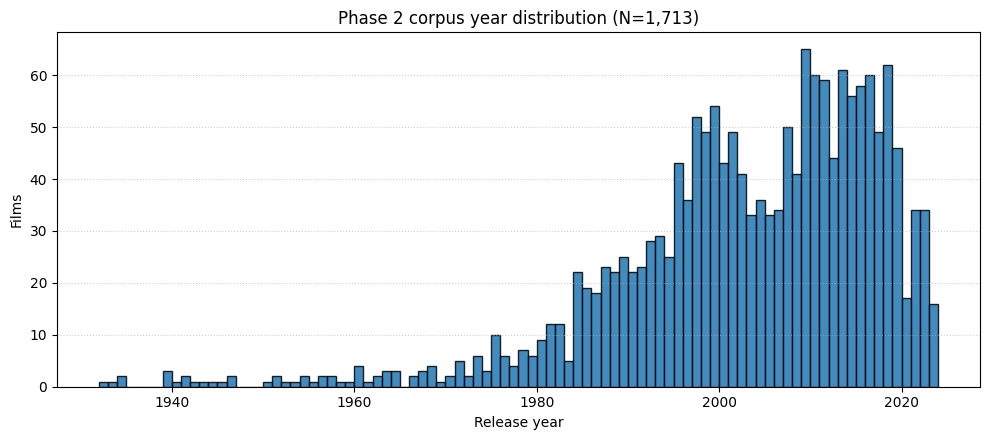

In [23]:
from src.data.validate_processed_corpus import plot_year_distribution

plot_year_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_year_distribution.png"
)
plt.show()

The corpus exhibits a dense main body covering 1995 to
2022 and a thinner historical tail extending to 1932.
Era-stratified cross-validation in Phase 4 will group
pre-1980s decades into a single stratum to ensure stable
per-decade estimates; per-decade cell counts are tabulated
in Section 12 below.

### 11.2 Genre distribution

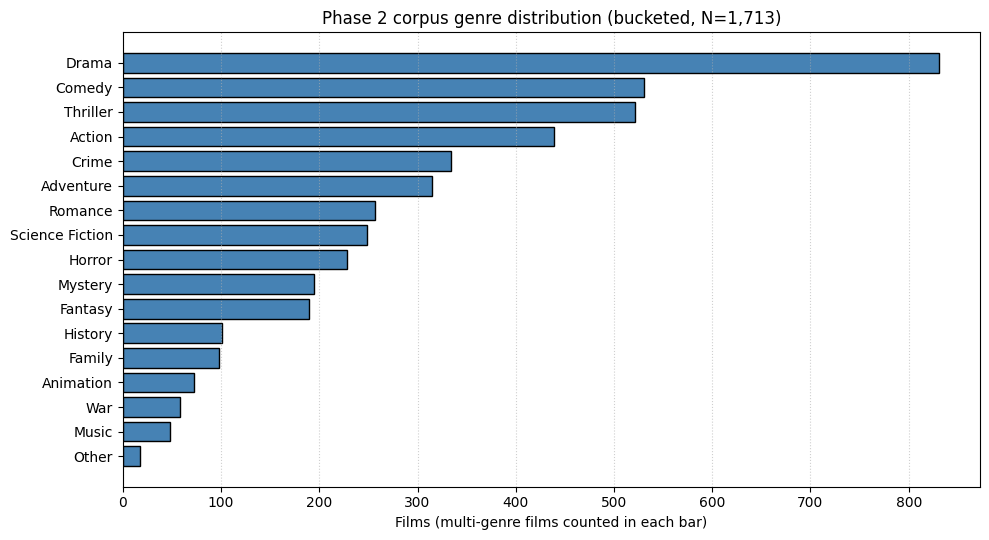

In [24]:
from src.data.validate_processed_corpus import plot_genre_distribution

plot_genre_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_genre_distribution.png"
)
plt.show()

Drama, Comedy, Action, and Horror lead the distribution.
Genres with population below thirty films have been
collapsed into the `Other` category, ensuring that
per-genre stratified analyses in Phase 4 operate on
well-conditioned cells.

### 11.3 Budget and revenue distributions (raw and log scales)

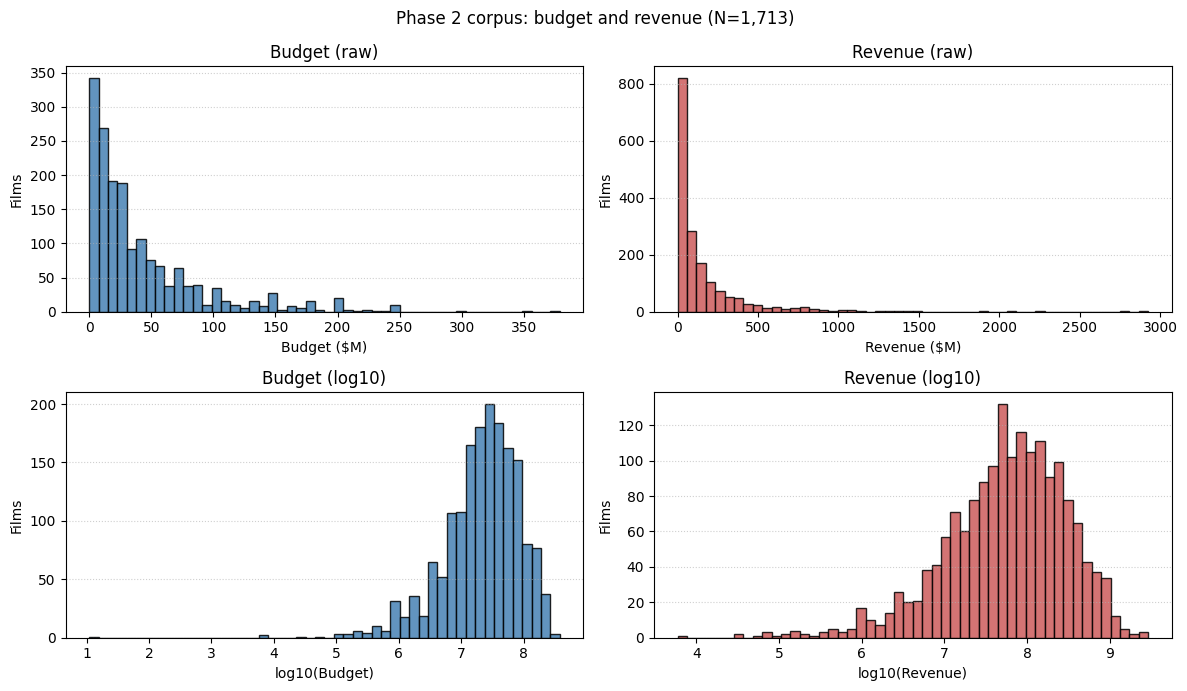

In [25]:
from src.data.validate_processed_corpus import plot_budget_revenue

plot_budget_revenue(
    df, paths.REPORTS_FIGURES_DIR / "phase2_budget_revenue_distribution.png"
)
plt.show()

The raw-scale histograms exhibit pronounced right-skew
that motivates the logarithmic transform discussed in
Section 6.2. Median budget is $25M and median revenue is
$64M; the means are substantially higher ($42M and $154M
respectively), reflecting the heavy upper tail. The
log10-transformed panels display approximately symmetric
unimodal distributions, suitable inputs for downstream
regression modelling.

### 11.4 Rating, ROI, and screenplay length

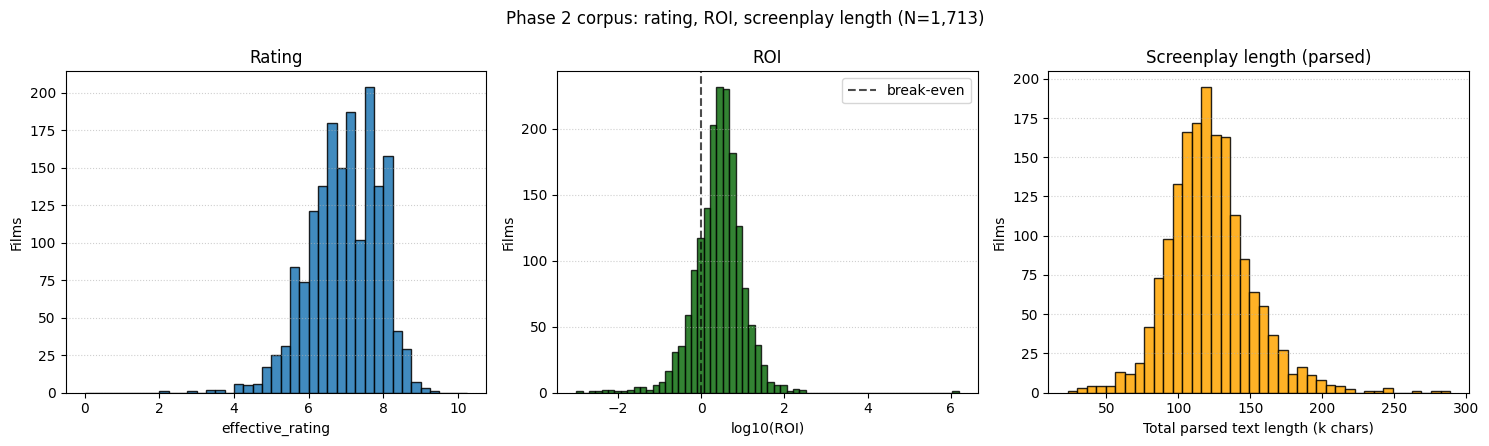

In [26]:
from src.data.validate_processed_corpus import plot_rating_roi_length

plot_rating_roi_length(
    df, paths.REPORTS_FIGURES_DIR / "phase2_rating_roi_length.png"
)
plt.show()

The rating distribution has mean 6.94 and standard
deviation 0.92, with median 7.0. The relatively narrow
spread constrains the achievable predictive coefficient
of determination in Phase 4; the project's novelty
contribution is therefore concentrated in the downstream
layers (calibrated uncertainty in Phase 5,
asymmetric-cost decision-making in Phase 6) rather than
in headline regression accuracy.

The return-on-investment distribution is heavily
right-tailed, with the break-even line (log10 ROI = 0)
positioned to the left of the bulk of the distribution.
Approximately 80.5 percent of films in the corpus are
gross-profitable; this rate substantially exceeds the
industry's net-profitability rate of approximately 50
percent, reflecting survivorship bias in the corpus
(films that were both produced and recognized enough to
appear in a major metadata aggregator). Phase 6's cost
matrix is therefore calibrated against external industry
base rates rather than corpus rates, with sensitivity
analysis across alternative cost matrices in Phase 8.

The screenplay-length distribution (parsed text:
dialogue plus action) has median ≈ 120,000 characters
and is approximately bell-shaped. Note that the parsed
text length is shorter than the raw XML's character
count (≈ 210,000 characters), as the raw count includes
XML tags and structural markup that are not part of the
screenplay's narrative content.

### 11.5 Screenplay-structural features

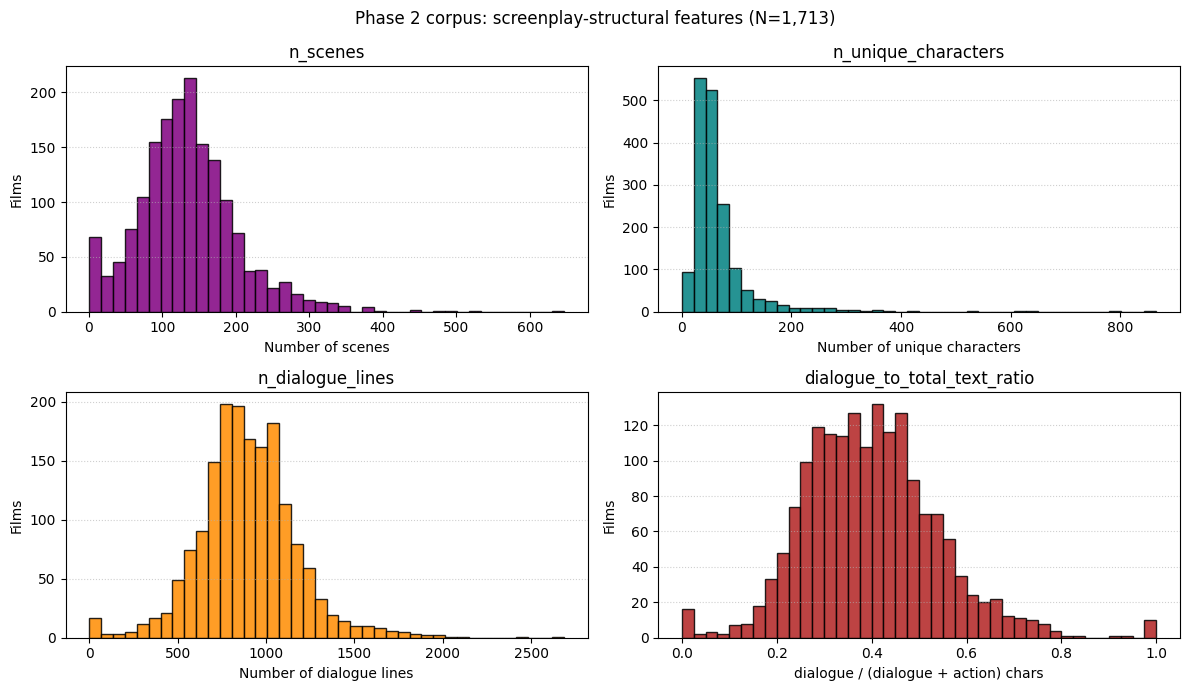

In [27]:
from src.data.validate_processed_corpus import plot_screenplay_structure

plot_screenplay_structure(
    df, paths.REPORTS_FIGURES_DIR / "phase2_screenplay_structure.png"
)
plt.show()

Four structural distributions characterize the parsed
screenplays:

* `n_scenes`: right-skewed, median 130, mean 135. Six
  films exceed 400 scenes. The lower tail (films with
  fewer than 10 scenes) reflects source-XML degeneracy
  rather than genuinely short screenplays; these films
  carry `data_quality_flag = True` (Section 8.5).
* `n_unique_characters`: right-skewed, median 51, mean 65.
  Approximately 51 films exceed 200 unique characters,
  corresponding to ensemble works or films with extensive
  background-character cataloguing in their screenplays.
* `n_dialogue_lines`: right-skewed, median 880, mean 895.
  The distribution mirrors total parsed-text length.
* `dialogue_to_total_text_ratio`: approximately
  bell-shaped, mean 0.40, median 0.39. About 125 films
  (7%) exceed 0.6, indicating dialogue-dominated
  screenplays; about 211 films (12%) fall below 0.25,
  indicating action-dominated screenplays. The dispersion
  reflects genuine stylistic variation between
  screenplays and is expected to carry meaningful
  predictive signal in Phase 3.

---

## 12. Per-decade and per-genre summary tables

The two tables below inform Phase 4's stratification
design and are saved as CSV files under `reports/tables/`.

### 12.1 Per-decade summary

In [28]:
from src.data.validate_processed_corpus import per_decade_table
per_decade_table(df)

,decade,n_films,budget_median_M,revenue_median_M,rating_mean,scenes_median,dialogue_lines_median
0,1930,7,0.70,4.50,7.63,2.0,1363.0
1,1940,9,0.88,4.90,8.00,76.0,1061.0
2,1950,14,1.24,9.00,7.91,92.5,1004.5
3,1960,23,2.50,25.00,7.81,98.0,870.0
4,1970,51,3.50,46.67,7.40,90.0,869.0
5,1980,167,15.00,44.80,6.86,128.0,810.0
6,1990,361,30.00,59.49,6.86,127.0,883.0
7,2000,425,40.00,83.28,6.88,141.0,896.0
8,2010,555,25.00,77.07,6.96,130.0,883.0
9,2020,101,35.00,46.33,6.84,117.0,914.0


Per-decade cell counts are: 1930s (7), 1940s (9), 1950s
(14), 1960s (23), 1970s (51), 1980s (167), 1990s (361),
2000s (425), 2010s (555), and 2020s (101 partial). Each
of the 1930s through 1960s decades contains fewer than
thirty films and would produce noisy per-stratum
estimates if treated independently. These four decades
will be consolidated into a single "older films" stratum
for Phase 4 cross-validation. The 1970s onwards have
well-conditioned cell sizes and can be treated as
independent strata.

### 12.2 Per-genre summary

In [29]:
from src.data.validate_processed_corpus import per_genre_table
per_genre_table(df)

,primary_genre_bucketed,n_films,budget_median_M,revenue_median_M,rating_mean,roi_median
5,Drama,431,18.00,40.26,7.09,2.55
3,Comedy,312,18.00,52.50,6.72,3.01
0,Action,239,55.00,139.20,6.92,2.52
9,Horror,147,11.00,47.97,6.63,4.03
1,Adventure,121,65.00,263.92,7.17,3.23
4,Crime,101,18.00,45.28,7.15,2.57
15,Thriller,83,32.00,78.87,6.88,2.48
14,Science Fiction,66,40.00,92.69,6.94,2.46
7,Fantasy,47,54.00,151.93,7.00,3.15
2,Animation,45,80.00,348.84,7.21,3.84


Drama is the largest primary-genre bucket (431 films),
followed by Comedy (312) and Action (239). Per-genre
median budget, revenue, and rating values reveal
systematic differences between genres: Action and
Adventure films have the highest median budgets and
revenues; Drama films have the highest median ratings;
Horror exhibits low median budgets paired with high
median return-on-investment. These differences support
the inclusion of genre as an important feature group in
Phase 3.

---

## 13. Phase 2 Conclusion

### Outputs

* `data/processed/films_joined.parquet`: 1,713 films
  across 42 columns (source metadata, derived columns,
  screenplay-structural metrics, `data_quality_flag`).
* `data/processed/screenplays_parsed.pkl`: 1,713
  `ParsedScreenplay` objects with full per-scene
  structure.
* Six diagnostic figures and four summary tables under
  `reports/figures/` and `reports/tables/`, named with
  the `phase2_` prefix.
* `docs/DATA_NOTES.md`: a standing reference document
  comprising the column glossary, known biases, and
  edge-case documentation.

### Key methodological notes for downstream phases

* **Sentinel encoding for monetary fields.** The values
  `budget = 0` and `revenue = 0` are missing-data
  sentinels inherited from the ratings source. The
  processed corpus excludes such rows; any future
  analysis that re-loads the raw data must re-apply
  this convention.
* **Survivorship bias.** The corpus is biased toward
  films that were both produced and well-recognized,
  with a gross profitability rate substantially above
  the industry net rate. Phase 6's cost matrix uses
  external industry rates, and Phase 8 conducts
  sensitivity analysis across alternative cost
  configurations.
* **`<parenthetical>` elements.** Recognized as
  continuation markers but not stored separately; the
  `dialogue_units` schema specifies two-tuples of
  `(character, dialogue_text)`.
* **Two dialogue-to-action ratios available.** Phase 3
  selects the form appropriate to each engineered
  feature.
* **Configuration knobs.** All preprocessing decisions
  discussed above are exposed as parameters in
  `CorpusBuildConfig`. Alternative configurations
  (different year cutoffs, alternative monetary
  transforms, alternative bucketing thresholds) can be
  evaluated by overriding the relevant fields and
  rebuilding.
* **`data_quality_flag` for degenerate scene structure.**
  Thirty films carry the flag (`n_scenes < 10 AND
  total_dialogue_chars > 50,000`); per-scene analyses
  on these films are unreliable. Phase 3 decides
  handling.
* **`n_unique_characters` and `parse_warning_count`
  carry overlapping information** (Spearman ρ ≈ +0.39).
  Including both as features in Phase 4 modelling risks
  redundancy; the relationship reflects a genuine
  underlying-data property (large-cast films
  encountering more source-XML formatting variance),
  not a parser artifact.

### Inputs to Phase 3

Phase 3 reads `films_joined.parquet` for film-level
metadata and outcomes, and `screenplays_parsed.pkl` for
per-scene structure. Phase 3 will:

1. Construct a train / calibration / test partition of
   the corpus.
2. Define and apply post-split imputation strategies.
3. Extract dialogue features (lexical, sentiment, topic,
   embedding, structural).
4. Save the resulting feature matrix to
   `data/processed/features.parquet`.

Detailed column documentation is available in
`docs/DATA_NOTES.md`. Methodological rationale and
audit trail are documented in
`docs/summaries/phase_2_summary.md`.